Kernel density estimation, Irreducible mass

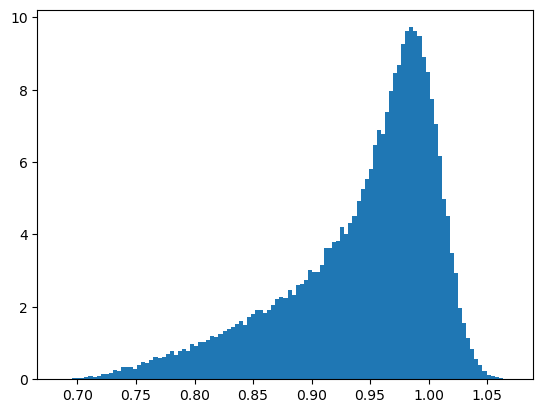

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization.hist import hist
import scipy.stats
from tqdm import tqdm

mean = 1
std = 0.02


chi = np.random.uniform(0, 1, 100000)

M = np.random.normal(mean, std, 100000)

M_irr = M*np.sqrt((1+np.sqrt(1-chi**2))/2)

x = np.linspace(min(M_irr), max(M_irr))

hist(M_irr, bins="freedman", density=True);

In [2]:
from sklearn.neighbors import KernelDensity

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(x[:, np.newaxis]) # sklearn returns log(density)

    return np.exp(log_pdf)

KDE = kde_sklearn(M_irr, bandwidth=0.1, kernel="linear")

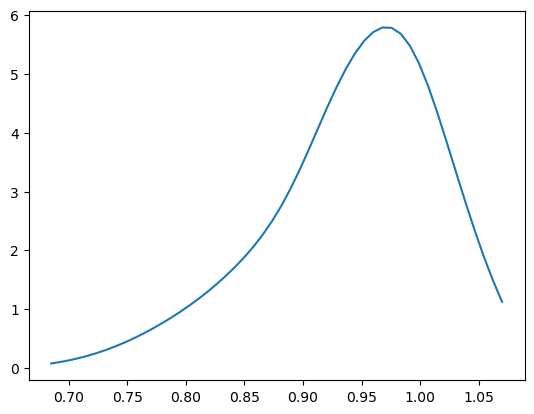

In [3]:
plt.plot(x, KDE)

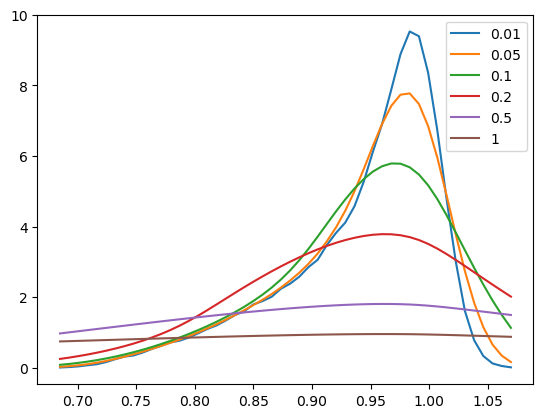

In [4]:
for i in [0.01, 0.05, 0.1, 0.2, 0.5, 1]:
    KDE = kde_sklearn(M_irr, bandwidth=i, kernel="linear")
    plt.plot(x, KDE, label=i)

plt.legend()

In [5]:
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import uniform
import scipy.stats
from scipy import optimize
from astroML import stats as astroMLstats

f = np.sqrt((1+np.sqrt(1-chi**2))/2)
print(stats.ks_2samp(M_irr, f))                 #mean = 1

KstestResult(statistic=0.15971999999999997, pvalue=0.0, statistic_location=0.9999999998103675, statistic_sign=-1)


In [6]:
#do it for many sigmas

sigmas = np.logspace(-3, 1, 100)
ks_Mirr_f = []
ks_Mirr_M = []

for i in sigmas:
    M = np.random.normal(mean, i, 100000)
    M_irr = M*np.sqrt((1+np.sqrt(1-chi**2))/2)
    f = M_irr/M
    
    ks_Mirr_f.append(scipy.stats.kstest(M_irr, f))
    ks_Mirr_M.append(scipy.stats.kstest(M_irr, M))

In [7]:
print(ks_Mirr_f[1])
ks_Mirr_f = np.array(ks_Mirr_f)
ks_Mirr_M = np.array(ks_Mirr_M)
print(ks_Mirr_f)

KstestResult(statistic=0.03808, pvalue=1.965704313662129e-63, statistic_location=0.9999999998103674, statistic_sign=-1)
[[3.68900000e-002 1.48182442e-059]
 [3.80800000e-002 1.96570431e-063]
 [3.96700000e-002 8.32936920e-069]
 [4.28300000e-002 3.88241875e-080]
 [4.24900000e-002 7.08030643e-079]
 [4.58000000e-002 1.40057204e-091]
 [4.86200000e-002 3.71823954e-103]
 [5.06600000e-002 5.81179436e-112]
 [5.28900000e-002 5.28630412e-122]
 [5.59500000e-002 1.73394113e-136]
 [5.87100000e-002 2.98126274e-150]
 [6.06700000e-002 1.97653124e-160]
 [6.31800000e-002 5.90900824e-174]
 [6.72900000e-002 2.74116553e-197]
 [6.99200000e-002 5.39846376e-213]
 [7.32300000e-002 1.27733165e-233]
 [7.64600000e-002 1.13458490e-254]
 [7.96900000e-002 1.23044589e-276]
 [8.49700000e-002 1.64602130e-314]
 [8.82300000e-002 0.00000000e+000]
 [9.20100000e-002 0.00000000e+000]
 [9.64700000e-002 0.00000000e+000]
 [1.00870000e-001 0.00000000e+000]
 [1.05950000e-001 0.00000000e+000]
 [1.10210000e-001 0.00000000e+000]
 [1.1

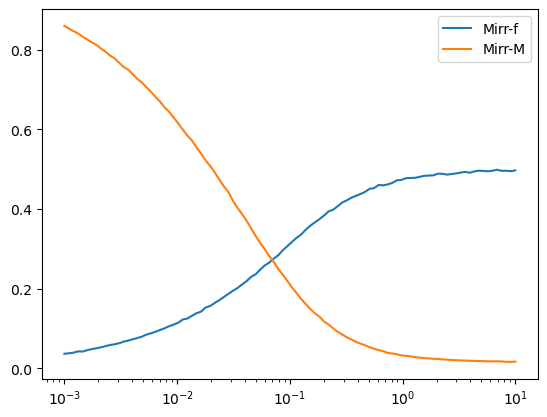

In [8]:
plt.plot(sigmas, ks_Mirr_f[:,0], label="Mirr-f")
plt.plot(sigmas, ks_Mirr_M[:,0], label="Mirr-M")
plt.xscale("log")
plt.legend()

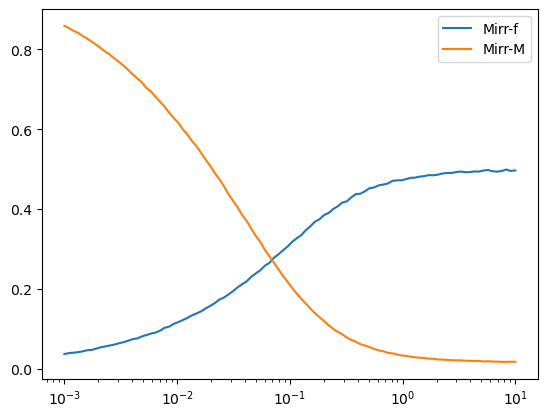

In [9]:
#check what happens if you use ks_2samp

ks_Mirr_f = []
ks_Mirr_M = []

for i in sigmas:
    M = np.random.normal(mean, i, 100000)
    M_irr = M*np.sqrt((1+np.sqrt(1-chi**2))/2)
    f = M_irr/M
    
    ks_Mirr_f.append(scipy.stats.ks_2samp(M_irr, f))
    ks_Mirr_M.append(scipy.stats.ks_2samp(M_irr, M))

ks_Mirr_f = np.array(ks_Mirr_f)
ks_Mirr_M = np.array(ks_Mirr_M)

plt.plot(sigmas, ks_Mirr_f[:,0], label="Mirr-f")
plt.plot(sigmas, ks_Mirr_M[:,0], label="Mirr-M")
plt.xscale("log")
plt.legend()

In [10]:
def integrand(f,x):
    return ((2/np.pi)**0.5 / std ) * np.exp(-(x/f -1)**2 /(2*std**2)) * (2*f**2-1)/(1 - f**2)**0.5 / f

Mirr = [scipy.integrate.quad(lambda f: integrand(f, xt), 1/2**0.5,1)[0] for xt in x]

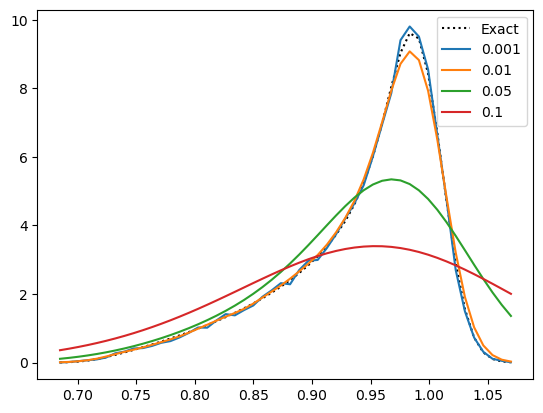

In [11]:
plt.plot(x, Mirr, label='Exact', c='black', ls='dotted')

#redefine M_irr because I updated it while computing the ks test for different sigmas
M = np.random.normal(mean, std, 100000)
M_irr = M*np.sqrt((1+np.sqrt(1-chi**2))/2)

for i in [0.001, 0.01, 0.05, 0.1]:
    KDE = kde_sklearn(M_irr, bandwidth=i, kernel="gaussian")
    plt.plot(x, KDE, label=i)

plt.legend()